In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [9]:
housing_data = pd.read_csv('housing.csv')
housing_data.head()
print(housing_data.shape)


(16512, 10)


In [7]:
housing_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-117.61,34.13,21.0,8416.0,1386.0,4308.0,1341.0,4.4611,INLAND,164600.0
1,-117.37,33.98,52.0,201.0,44.0,130.0,24.0,2.0250,INLAND,125000.0
2,-118.34,33.89,36.0,2274.0,411.0,1232.0,423.0,5.3730,<1H OCEAN,244500.0
3,-118.92,35.13,29.0,1297.0,262.0,909.0,253.0,1.9236,INLAND,106300.0
4,-121.80,37.23,18.0,3179.0,526.0,1663.0,507.0,5.9225,<1H OCEAN,265800.0
...,...,...,...,...,...,...,...,...,...,...
16507,-119.53,36.55,34.0,2065.0,343.0,1041.0,313.0,3.2917,INLAND,111500.0
16508,-122.40,37.73,50.0,1947.0,411.0,1170.0,384.0,3.4769,NEAR BAY,238700.0
16509,-118.41,33.92,29.0,1436.0,401.0,674.0,343.0,3.6389,<1H OCEAN,275000.0
16510,-117.08,32.62,36.0,1674.0,309.0,818.0,307.0,3.4773,NEAR OCEAN,150400.0


In [6]:
x = housing_data
cat_col = 'ocean_proximity'
num_cols = x.select_dtypes(include=[np.number]).columns.tolist()
x[num_cols] = x[num_cols].fillna(x[num_cols].median())
x

/Users/thomascherqui/Desktop/Imperial/Term 1/Introduction to Machine Learning/Neural_Networks_70050_092/my_env/lib/python3.14/site-packages/pandas/core/generic.py:7387: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-117.61,34.13,21.0,8416.0,1386.0,4308.0,1341.0,4.4611,INLAND,164600.0
1,-117.37,33.98,52.0,201.0,44.0,130.0,24.0,2.0250,INLAND,125000.0
2,-118.34,33.89,36.0,2274.0,411.0,1232.0,423.0,5.3730,<1H OCEAN,244500.0
3,-118.92,35.13,29.0,1297.0,262.0,909.0,253.0,1.9236,INLAND,106300.0
4,-121.80,37.23,18.0,3179.0,526.0,1663.0,507.0,5.9225,<1H OCEAN,265800.0
...,...,...,...,...,...,...,...,...,...,...
16507,-119.53,36.55,34.0,2065.0,343.0,1041.0,313.0,3.2917,INLAND,111500.0
16508,-122.40,37.73,50.0,1947.0,411.0,1170.0,384.0,3.4769,NEAR BAY,238700.0
16509,-118.41,33.92,29.0,1436.0,401.0,674.0,343.0,3.6389,<1H OCEAN,275000.0
16510,-117.08,32.62,36.0,1674.0,309.0,818.0,307.0,3.4773,NEAR OCEAN,150400.0


In [3]:
def one_hot_encode(data:pd.DataFrame):
    
    categorical_features = data.select_dtypes(exclude=[np.number]).columns.tolist()
    returnArray = data
    for ftr in categorical_features:
        uniqueList = np.unique(data[ftr])
        for val in uniqueList:
            colName = ftr + str(val)
            def row_lambda(row):
                if row[ftr] == val:
                    return 1
                else:  
                    return 0
            returnArray[colName] = returnArray.apply(row_lambda, axis=1)
        returnArray = returnArray.drop(columns=[ftr])
    

    return returnArray

In [4]:
array = one_hot_encode(housing_data)
array.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity<1H OCEAN',
       'ocean_proximityINLAND', 'ocean_proximityISLAND',
       'ocean_proximityNEAR BAY', 'ocean_proximityNEAR OCEAN'],
      dtype='object')

In [5]:
def impute_missing_data(data, method='mean'):
    if method == "mean":
        data =  data.fillna(data.mean)
    if method == "median":
        data =  data.fillna(data.mean)

    return data


Number of samples: 16512
count     16512.000000
mean     207251.882994
std      115687.033147
min       14999.000000
25%      120000.000000
50%      179800.000000
75%      264525.000000
max      500001.000000
Name: median_house_value, dtype: float64


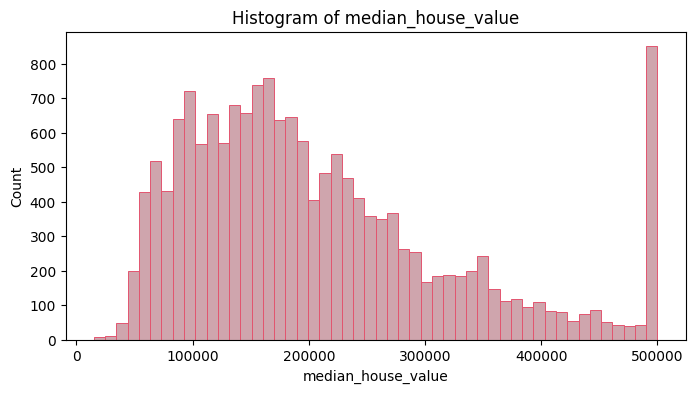


Observation: the distribution is usually right-skewed with a concentration at lower values and a few high-value outliers.


In [6]:
df=array

### Inspect target distribution
label = 'median_house_value'
print('Number of samples:', df.shape[0])
print(df[label].describe())

# Plot histogram of the target (one matplotlib plot)
plt.figure(figsize=(8,4))
plt.hist(df[label].dropna(), bins=50, color= '#cfa5ad',edgecolor="#e2556f",   # contour rose légèrement plus foncé
linewidth=0.7)
plt.xlabel(label)
plt.ylabel('Count')
plt.title('Histogram of median_house_value')
plt.show()

print('\nObservation: the distribution is usually right-skewed with a concentration at lower values and a few high-value outliers.')

Missing values before imputation in 'total_bedrooms': 168

Distribution summary before imputation:


count    16344.000000
mean       538.522026
std        425.256071
min          1.000000
25%        295.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64


Skewness: 3.513


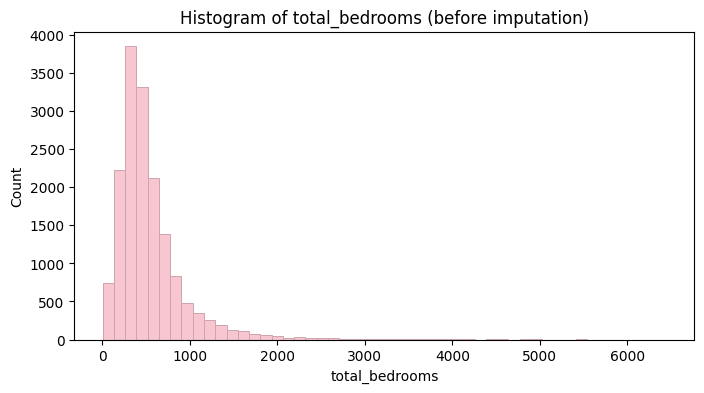


Missing values after imputation in 'total_bedrooms': 0

Distribution summary after imputation:


count    16512.000000
mean       537.468750
std        423.214579
min          1.000000
25%        296.000000
50%        435.000000
75%        644.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

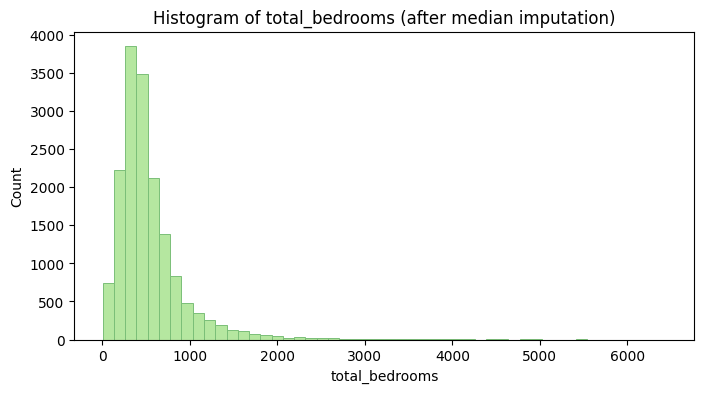

In [7]:
### Impute missing numeric values (total_bedrooms) using median

col = 'total_bedrooms'

# Afficher les informations avant imputation
print(f"Missing values before imputation in '{col}': {df[col].isnull().sum()}\n")
print("Distribution summary before imputation:")
display(df[col].describe())
print(f"\nSkewness: {df[col].skew():.3f}")

# Histogramme avant imputation
plt.figure(figsize=(8,4))
plt.hist(
    df[col].dropna(),
    bins=50,
    color='#f7c6d0',      # pale rose
    edgecolor='#cfa5ad',  # léger contour rose
    linewidth=0.7
)
plt.xlabel(col)
plt.ylabel("Count")
plt.title(f"Histogram of {col} (before imputation)")
plt.show()

# Imputation avec la médiane
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy='median')
df[[col]] = imp_median.fit_transform(df[[col]])

# Vérification après imputation
print(f"\nMissing values after imputation in '{col}': {df[col].isnull().sum()}\n")
print("Distribution summary after imputation:")
display(df[col].describe())

# Histogramme après imputation
plt.figure(figsize=(8,4))
plt.hist(
    df[col],
    bins=50,
    color='#b5e7a0',      # pastel green pour différencier
    edgecolor='#7bbf78',  # léger contour vert
    linewidth=0.7
)
plt.xlabel(col)
plt.ylabel("Count")
plt.title(f"Histogram of {col} (after median imputation)")
plt.show()


In [8]:
array.isna().sum().to_frame(name='NaN Count')

,NaN Count
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity<1H OCEAN,0


In [9]:
array = impute_missing_data(array)
array.isna().sum().to_frame(name='NaN Count')

,NaN Count
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity<1H OCEAN,0


In [10]:
array.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity<1H OCEAN,ocean_proximityINLAND,ocean_proximityISLAND,ocean_proximityNEAR BAY,ocean_proximityNEAR OCEAN
count,16512.00000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.00000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.55943,35.617896,28.669331,2639.225654,537.468750,1425.169513,499.902616,3.87329,207251.882994,0.442163,0.315104,0.000242,0.111737,0.130753
std,2.00348,2.134056,12.615046,2198.453859,423.214579,1147.038029,385.367776,1.91235,115687.033147,0.496659,0.464571,0.015563,0.315052,0.337141
min,-124.35000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.49990,14999.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-121.78250,33.930000,18.000000,1446.000000,296.000000,788.000000,279.000000,2.56250,120000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-118.49000,34.250000,29.000000,2122.000000,435.000000,1165.000000,410.000000,3.53410,179800.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-118.00000,37.710000,37.000000,3143.000000,644.000000,1718.000000,604.000000,4.73975,264525.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,-114.31000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.00010,500001.000000,1.000000,1.000000,1.000000,1.000000,1.000000
